In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("Manga_Fanfiction_WordCloud.jpg")

if img is None:
    raise FileNotFoundError("input.jpg not found")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Image Shape:", img.shape)

Image Shape: (1215, 2370, 3)


In [3]:
resized = cv2.resize(img, (500, 400))

h, w = img.shape[:2]
cropped = img[h//4:3*h//4, w//4:3*w//4]

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

negative = 255 - img

In [5]:
blurred = cv2.blur(img, (15, 15))
gaussian = cv2.GaussianBlur(img, (15, 15), 0)
median = cv2.medianBlur(img, 15)

In [7]:
bright = cv2.convertScaleAbs(img, alpha=1.2, beta=40)
dark = cv2.convertScaleAbs(img, alpha=0.8, beta=-30)
contrast = cv2.convertScaleAbs(img, alpha=1.8, beta=0)

In [9]:
canny = cv2.Canny(gray, 100, 200)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = cv2.convertScaleAbs(sobel)

In [10]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

In [11]:
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(img, -1, kernel)

In [12]:
rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
rotated_180 = cv2.rotate(img, cv2.ROTATE_180)

flip_horizontal = cv2.flip(img, 1)
flip_vertical = cv2.flip(img, 0)

In [13]:
rows, cols = img.shape[:2]

matrix = np.float32([
    [1, 0, 100],
    [0, 1, 50]
])

translated = cv2.warpAffine(img, matrix, (cols, rows))

In [14]:
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]

hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

In [15]:
equalized = cv2.equalizeHist(gray)

In [16]:
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

In [17]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contour_image = img.copy()
cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)

print("Contours detected:", len(contours))

Contours detected: 1


In [18]:
text_image = img.copy()

cv2.putText(
    text_image,
    "OpenCV Image Editing",
    (30, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 0, 0),
    2
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

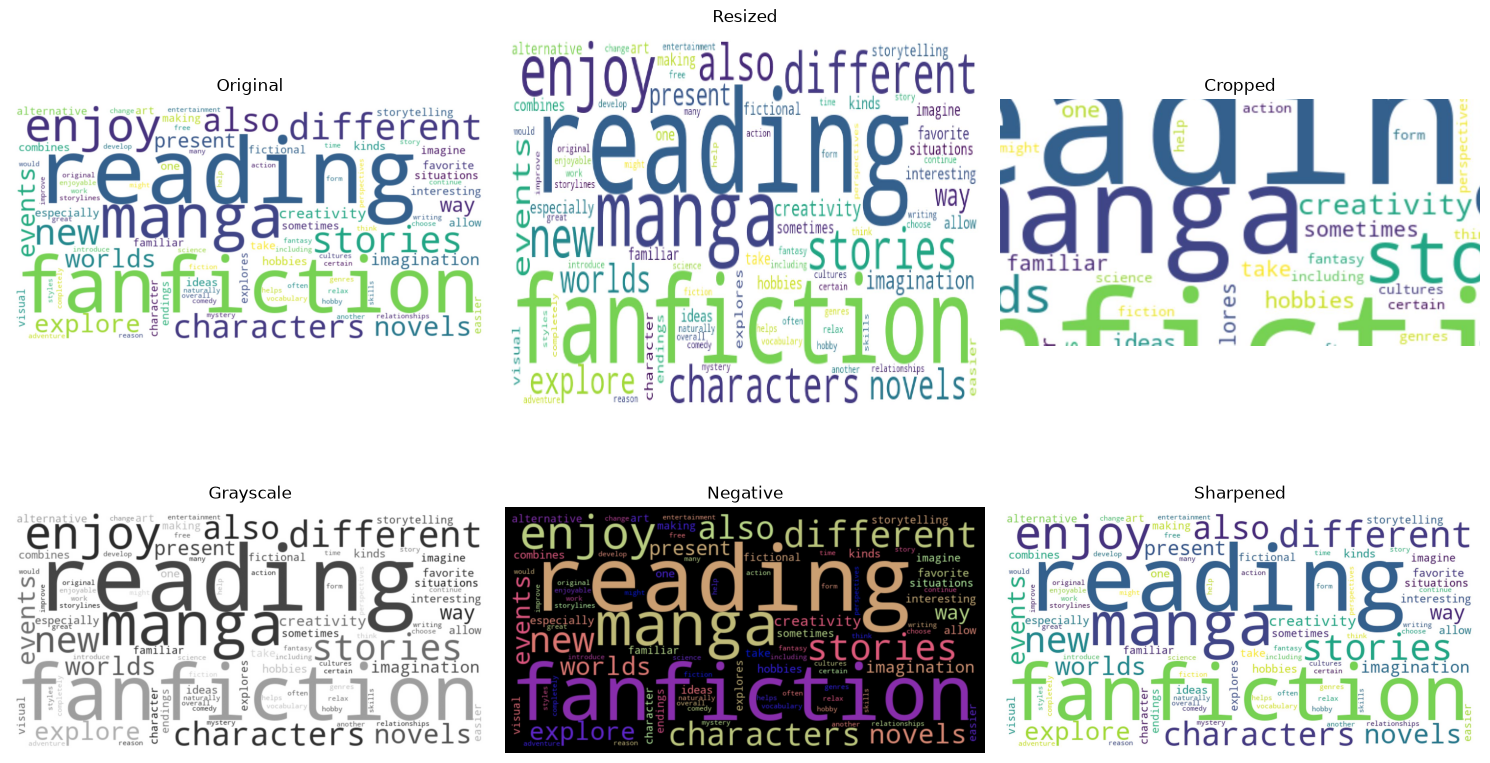

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    img,
    resized,
    cropped,
    gray,
    negative,
    sharpened
]

titles = [
    "Original",
    "Resized",
    "Cropped",
    "Grayscale",
    "Negative",
    "Sharpened"
]

for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image, cmap="gray" if len(image.shape) == 2 else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

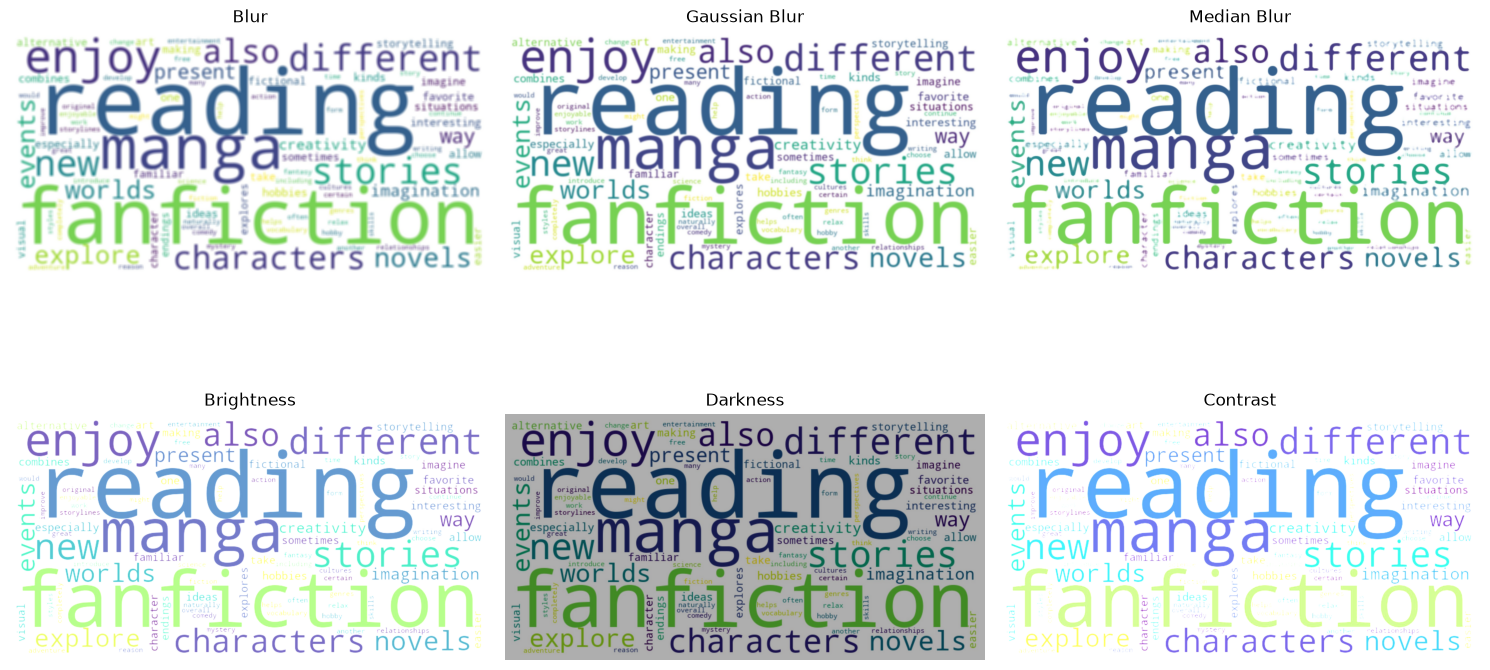

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    blurred,
    gaussian,
    median,
    bright,
    dark,
    contrast
]

titles = [
    "Blur",
    "Gaussian Blur",
    "Median Blur",
    "Brightness",
    "Darkness",
    "Contrast"
]

for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

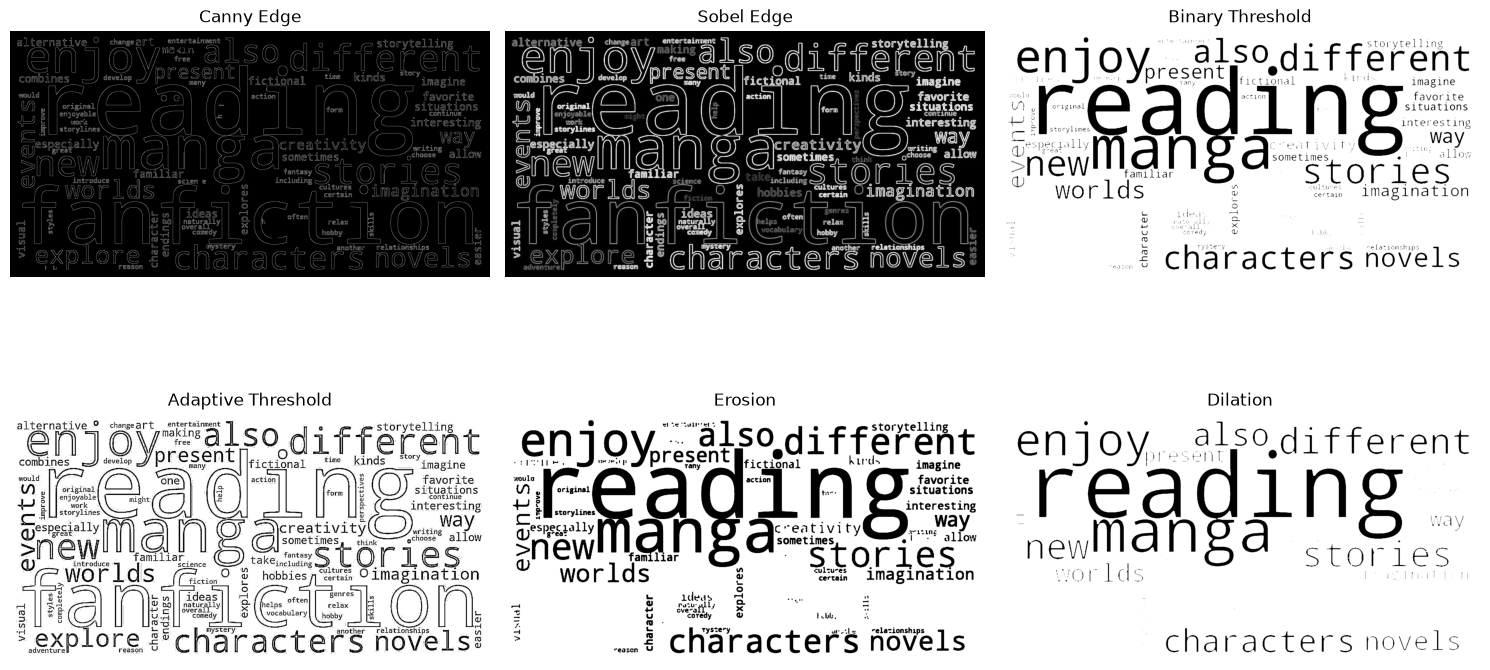

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    canny,
    sobel,
    binary,
    adaptive,
    erosion,
    dilation
]

titles = [
    "Canny Edge",
    "Sobel Edge",
    "Binary Threshold",
    "Adaptive Threshold",
    "Erosion",
    "Dilation"
]

for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

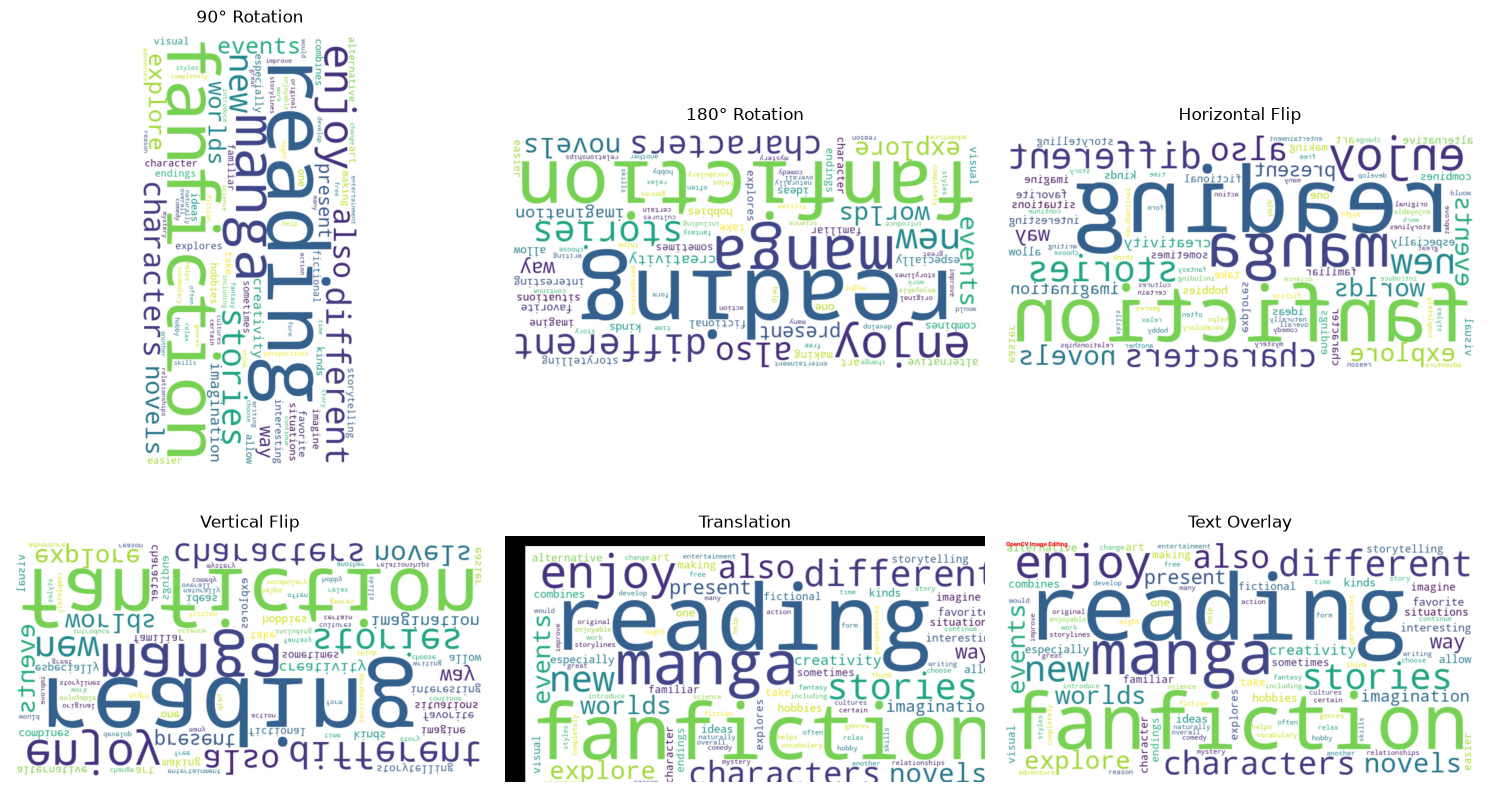

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    rotated_90,
    rotated_180,
    flip_horizontal,
    flip_vertical,
    translated,
    text_image
]

titles = [
    "90° Rotation",
    "180° Rotation",
    "Horizontal Flip",
    "Vertical Flip",
    "Translation",
    "Text Overlay"
]

for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

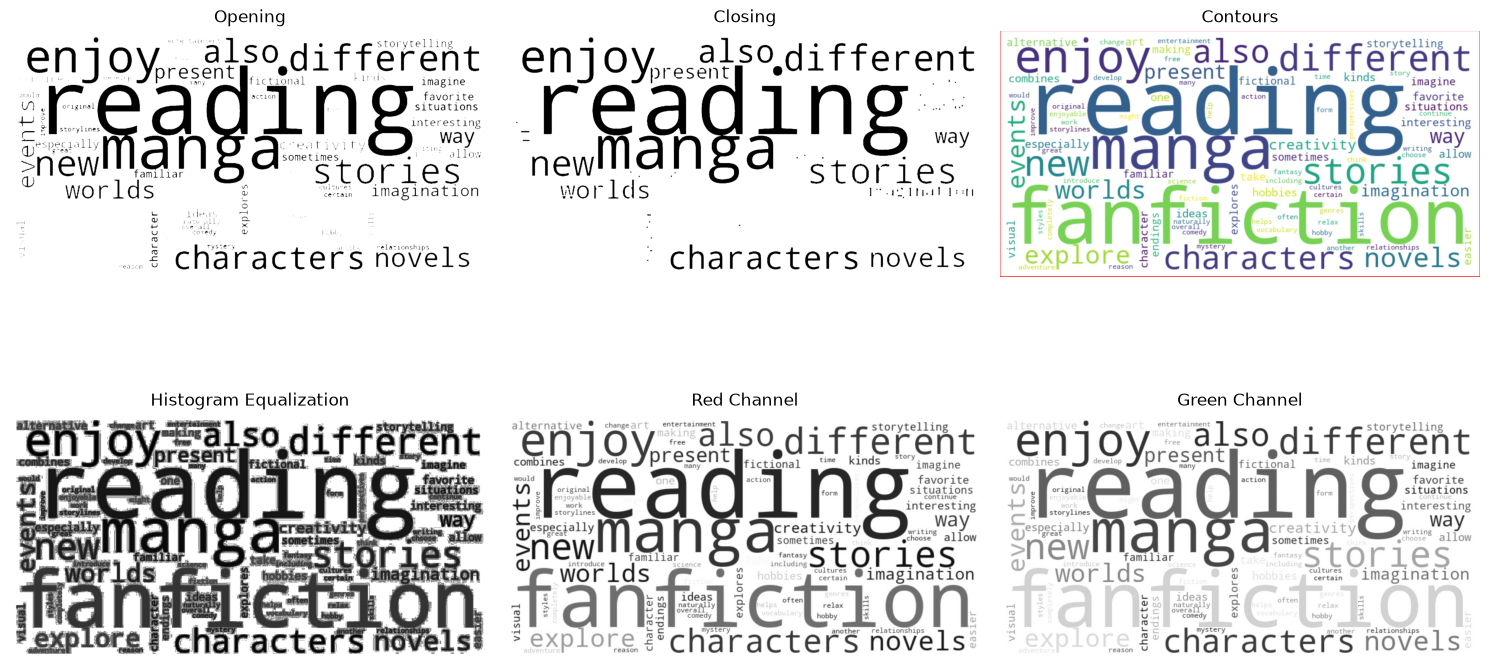

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    opening,
    closing,
    contour_image,
    equalized,
    red,
    green
]

titles = [
    "Opening",
    "Closing",
    "Contours",
    "Histogram Equalization",
    "Red Channel",
    "Green Channel"
]

for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image, cmap="gray" if len(image.shape) == 2 else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
cv2.imwrite("resized.jpg", cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))
cv2.imwrite("grayscale.jpg", gray)
cv2.imwrite("blurred.jpg", cv2.cvtColor(blurred, cv2.COLOR_RGB2BGR))
cv2.imwrite("sharpened.jpg", cv2.cvtColor(sharpened, cv2.COLOR_RGB2BGR))
cv2.imwrite("negative.jpg", cv2.cvtColor(negative, cv2.COLOR_RGB2BGR))
cv2.imwrite("edges.jpg", canny)
cv2.imwrite("rotated.jpg", cv2.cvtColor(rotated_90, cv2.COLOR_RGB2BGR))
cv2.imwrite("bright.jpg", cv2.cvtColor(bright, cv2.COLOR_RGB2BGR))
cv2.imwrite("contours.jpg", cv2.cvtColor(contour_image, cv2.COLOR_RGB2BGR))

print("All edited images saved successfully.")

All edited images saved successfully.
